# RLA + RLA-WM inference demo

Loads a trained **RLA** autoencoder and a **RLA-WM** flow-matching world model from `runs/weights/`, samples one trajectory from `data/maniskill`, and visualizes:

1. RLA reconstruction (encode → decode round-trip on the future frame).
2. RLA-WM future-frame prediction conditioned on the current frame, robot proprioception, and a target horizon.

All paths and the model selection live in **Cell 2** below — swap them to evaluate a different (config, weight-dir) pair.

In [1]:
# Cell 1 — imports + repo-root bootstrap
import os
import sys
import os.path as osp

_NOTEBOOK_DIR = osp.dirname(osp.abspath(globals().get('__vsc_ipynb_file__', os.getcwd())))
_REPO_ROOT = osp.abspath(osp.join(_NOTEBOOK_DIR, os.pardir))
if not osp.isfile(osp.join(_REPO_ROOT, 'train.py')):
    # Fallback when CWD is already the repo root.
    _REPO_ROOT = osp.abspath(os.getcwd())
for p in (_REPO_ROOT, osp.join(_REPO_ROOT, 'third_party', 'diffusion_policy')):
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(_REPO_ROOT)
print('Repo root:', _REPO_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from PIL import Image

from utils.misc import load_config
import src.models as models
import src.datasets as datasets
from src.trainers.rla_autoencoder_trainer import RlaAutoencoderTrainer
from src.trainers.rla_wm_trainer import RLAWMTrainer
from src.utils.loss_utils import ssim as compute_ssim, lpips as compute_lpips

Repo root: /common/users/xz653/Workspace/v4world-tmp


/common/users/xz653/Workspace/v4world-tmp/.venv/lib/python3.10/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/common/users/xz653/Workspace/v4world-tmp/.venv/lib/python3.10/site-packages/sapien/_vulkan_tricks.py:73: UserWarning: Failed to find Vulkan ICD file. This is probably due to an incorrect or partial installation of the NVIDIA driver. SAPIEN will attempt to provide an ICD file anyway but it may not work.
  warn(
2026-05-05 00:49:26,713 - mani_skill  - WARNING - Overriding registered agent panda
2026-05-05 00:49:26,717 - mani_skill  - WARNING - Overriding registered agent xarm6_robotiq
2026-05-05 00:49:26,803 - mani_skill  - WARNING - Env PokeCube-v1 is already registered. Skip registration.
2026-05-05 00:49:26,807 - mani_skill  

In [2]:
# Cell 2 — checkpoint switches (edit these to swap models)
RLA_CONFIG       = 'configs/rla/32x64.yaml'
RLA_WORKDIR      = 'runs/weights/rla/maniskill/20260323_21-41-25'

RLAWM_CONFIG     = 'configs/rla_wm/panda.yaml'
RLAWM_WORKDIR    = 'runs/weights/rla-wm/maniskill/panda/20260405_11-00-59'

IMG_DECODER_CKPT = 'runs/weights/dino-to-image_unet/maniskill/20260404_22-53-36'

DEVICE   = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
EULER_STEPS = 30
SAMPLE_INDEX = 0      # which dataset sample to visualize
SAMPLE_SEED  = 2026   # makes the sampling deterministic

# RLA-WM conditioning knobs. Defaults match the panda config above; for
# xarm/ur10e set ROBOT_ID accordingly (0=panda, 1=xarm6_robotiq, 2=ur10e_stick).
ROBOT_ID = 0
TASK_IND = 4   # see TASKS in src/datasets/trajectory_dataset.py (4 = PullCube-v2)
HORIZON  = 15  # rollout horizon used to pick frame_T from the trajectory

In [3]:
# Cell 3 — build inference-only trainers
#
# We instantiate each trainer in `inference_only` mode so the optimizer / EMA
# / dataloader paths are skipped. The pattern mirrors the helper used in
# scripts/flow_predictor/dino_latent_flow_predictor.py but is inlined here so
# this notebook stays self-contained.

def _build_models(cfg, device):
    return {
        name: getattr(models, m['name'])(**m['args']).to(device)
        for name, m in cfg['models'].items()
    }

def _trainer_kwargs(cfg, workdir, override_image_decoder_ckpt=None,
                    override_encoder_ckpt=None):
    kw = dict(cfg['trainer']['args'])
    kw.pop('load_dir', None)             # set explicitly below
    kw['batch_size'] = 1                  # we won't use the dataloader
    kw['num_workers'] = 0
    kw['skip_initial_snapshot'] = True
    if override_image_decoder_ckpt is not None:
        kw['image_decoder_ckpt'] = override_image_decoder_ckpt
    if override_encoder_ckpt is not None and 'encoder_ckpt' in kw:
        kw['encoder_ckpt'] = override_encoder_ckpt
    return kw

rla_cfg = load_config(RLA_CONFIG)
rla_models = _build_models(rla_cfg, DEVICE)
rla_trainer = RlaAutoencoderTrainer(
    rla_models,
    None,
    output_dir=RLA_WORKDIR,
    load_dir=RLA_WORKDIR,
    step=None,
    inference_only=True,
    **_trainer_kwargs(rla_cfg, RLA_WORKDIR,
                      override_image_decoder_ckpt=IMG_DECODER_CKPT),
)
for m in rla_trainer.models.values():
    m.eval()

rlawm_cfg = load_config(RLAWM_CONFIG)
rlawm_models = _build_models(rlawm_cfg, DEVICE)
rlawm_trainer = RLAWMTrainer(
    rlawm_models,
    None,
    output_dir=RLAWM_WORKDIR,
    load_dir=RLAWM_WORKDIR,
    step=None,
    inference_only=True,
    **_trainer_kwargs(rlawm_cfg, RLAWM_WORKDIR,
                      override_image_decoder_ckpt=IMG_DECODER_CKPT,
                      override_encoder_ckpt=RLA_WORKDIR),
)
for m in rlawm_trainer.models.values():
    m.eval()

print('RLA   models :', list(rla_trainer.models))
print('RLAWM models :', list(rlawm_trainer.models))

[SPARSE] Backend: spconv, Attention: flash_attn
[SPARSE][CONV] spconv algo: auto
[ATTENTION] Using backend: flash_attn


Freezing model: encoder

Freezing model: decoder

Freezing model: image_decoder

RlaAutoencoderTrainer: No dataset provided, skipping dataloader preparation.

...

Loading decoder from runs/weights/rla/maniskill/20260323_21-41-25/ckpts/decoder_step0100000.pt

Decoder loaded successfully (strict)

Loading decoder from runs/weights/dino-to-image_unet/maniskill/20260404_22-53-36/ckpts/decoder_step0060000.pt

Image decoder loaded successfully (strict)

RLA   models : ['encoder', 'decoder', 'image_decoder']
RLAWM models : ['encoder', 'decoder', 'image_decoder', 'flow_model']


In [7]:
# Cell 4 — load one *successful* trajectory sample
#
# Re-use the dataset config from the RLA-WM yaml so num_frames/horizon match
# what the world model was trained for. We force the cache file to a notebook-
# local path so we don't pollute the training cache.
#
# Failed episodes often stagnate (object doesn't move much), which makes the
# future-frame prediction visually trivial. We scan trajectories and pick the
# SAMPLE_INDEX-th one whose ``success`` flag is True.

ds_args = dict(rlawm_cfg['dataset']['args'])
ds_args['manual_limit'] = 64  # scan a small pool to find successful episodes
ds_args['trajectory_info_cache_file'] = 'runs/cache/notebook/inference_demo_dataset.json'

dataset = datasets.TrajectoryDataset(**ds_args)
print(f'Dataset has {len(dataset)} valid starts; scanning for success==True ...')

torch.manual_seed(SAMPLE_SEED)
np.random.seed(SAMPLE_SEED)

sample = None
chosen_idx = None
hits = 0
for i in range(len(dataset)):
    cand = dataset[i]
    if bool(np.asarray(cand['success']).reshape(-1)[0]):
        if hits == SAMPLE_INDEX:
            sample = cand
            chosen_idx = i
            break
        hits += 1
if sample is None:
    raise RuntimeError(
        f'No successful episode found in first {len(dataset)} starts; '
        'increase manual_limit or lower SAMPLE_INDEX.'
    )

print(f'Picked successful sample at dataset index {chosen_idx} (success #{SAMPLE_INDEX})')
for k in ('rgbs', 'foreground_masks', 'target_qpos'):
    v = sample[k]
    print(f'  {k:<18} shape={tuple(v.shape)} dtype={v.dtype}')


Found trajectory_info cache: runs/cache/notebook/inference_demo_dataset.json

Using trajectory_info from cache (5930 trajectories)

Filtered out 13 trajectories that are too short for horizon 2-15.

Dataset Summary:

play_panda: 2957 trajectories, 494850 frames (187887 interaction)

...

└ data/maniskill/ppo/panda/PullCube-v2/success: 990 trajectories, 19758 frames (13208 interaction)

└ data/maniskill/ppo/panda/PullCubeTool-v1/fail: 490 trajectories, 73500 frames (53445 interaction)

└ data/maniskill/ppo/panda/PullCubeTool-v1/success: 990 trajectories, 56738 frames (53864 interaction)

Total: 5917 trajectories, 718346 frames

Dataset has 64 valid starts; scanning for success==True ...
Picked successful sample at dataset index 2 (success #0)
  rgbs               shape=(2, 1, 3, 512, 512) dtype=uint8
  foreground_masks   shape=(2, 1, 512, 512) dtype=uint8
  target_qpos        shape=(10, 1, 8) dtype=float32


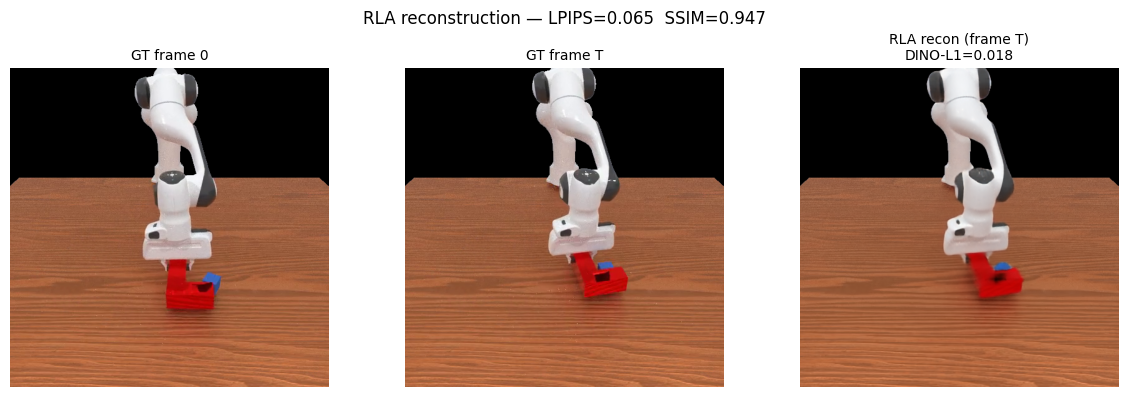

In [8]:
# Cell 5 — RLA reconstruction
#
# Encode the future frame's DINO tokens through the RLA autoencoder and
# decode them back to image space.

def _to_tensor(x):
    if torch.is_tensor(x):
        return x
    return torch.from_numpy(np.asarray(x))

def _tensor_to_pil(t):
    if t.dim() == 4:
        t = t[0]
    return TF.to_pil_image(t.clamp(0, 1).cpu())

def _show_row(images, titles, suptitle=None):
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    for ax, img, ttl in zip(axes, images, titles):
        ax.imshow(img)
        ax.set_title(ttl, fontsize=10)
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

rgbs = _to_tensor(sample['rgbs']).to(DEVICE)            # (T, Cam, 3, H, W) uint8
masks = _to_tensor(sample['foreground_masks']).to(DEVICE)
mask_f = (masks > 0).float().unsqueeze(2)               # (T, Cam, 1, H, W)
masked = rgbs.float() * mask_f / 255.0                  # [0, 1]

# RLA round-trip on frames 0 (current) and 1 (future).
with torch.no_grad():
    rla_tokens, patch_hw = rla_trainer._extract_dino_tokens(masked[:, :1])  # (T, 1, Lp, C)
    x_t = rla_tokens[0]    # (1, Lp, C)
    x_T = rla_tokens[1]
    latent, _ = rla_trainer.models['encoder']((x_T - x_t).float())
    _, recon_x_T = rla_trainer.models['decoder'](x_t, tokens=latent)
    recon_img = rla_trainer.models['image_decoder'](
        recon_x_T.unsqueeze(1).contiguous(), patch_hw=patch_hw
    )[:, 0].clamp(0, 1)

gt_t_pil    = _tensor_to_pil(masked[0, 0])
gt_T_pil    = _tensor_to_pil(masked[1, 0])
recon_pil   = _tensor_to_pil(recon_img)

dino_l1 = F.l1_loss(recon_x_T.float(), x_T.float()).item()
lpips_v = compute_lpips(recon_img, masked[1, :1]).item()
ssim_v  = compute_ssim(recon_img, masked[1, :1]).item()

_show_row(
    [gt_t_pil, gt_T_pil, recon_pil],
    ['GT frame 0', 'GT frame T', f'RLA recon (frame T)\nDINO-L1={dino_l1:.3f}'],
    suptitle=f'RLA reconstruction — LPIPS={lpips_v:.3f}  SSIM={ssim_v:.3f}',
)

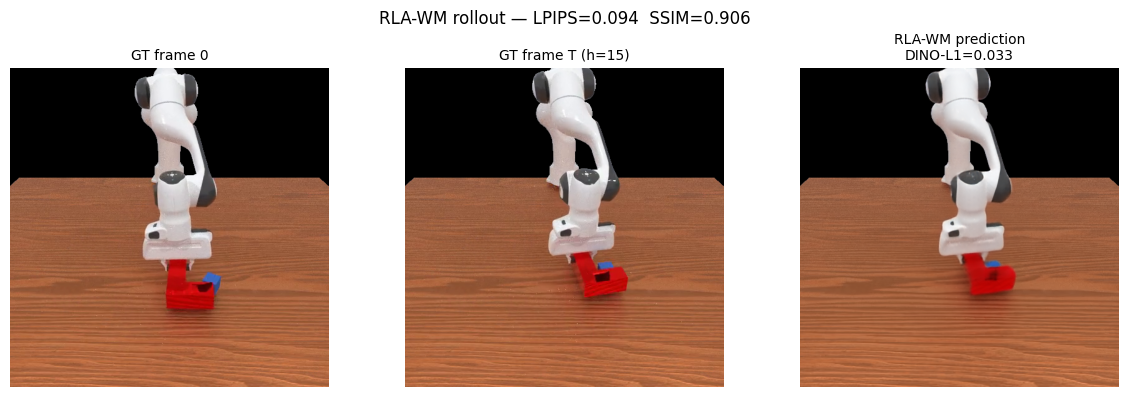

In [9]:
# Cell 6 — RLA-WM future-frame prediction
#
# Feed frame 0's DINO tokens into RLA-WM, sample latent action tokens via
# Euler-integrated flow matching conditioned on (target_qpos, horizon, robot,
# task), decode them through the (frozen) RLA decoder and image decoder.

with torch.no_grad():
    rgbs1 = masked[:, :1]                                   # (T, 1, 3, H, W)
    wm_tokens, wm_patch_hw = rlawm_trainer._extract_dino_tokens(rgbs1)
    x_t_wm = wm_tokens[0].float()                          # (1, Lp, C)
    x_T_wm = wm_tokens[1].float()

    target_qpos = _to_tensor(sample['target_qpos']).to(DEVICE).float()
    robot_ids = torch.tensor([ROBOT_ID], device=DEVICE)
    task_inds = torch.tensor([TASK_IND], device=DEVICE)
    horizons  = torch.tensor([HORIZON], device=DEVICE, dtype=torch.float)

    full_qpos_list = rlawm_trainer._target_qpos_to_full_qpos(
        [target_qpos], robot_ids, task_inds,
    )

    flow_model = rlawm_trainer.models['flow_model']
    num_lat = flow_model.num_tokens if hasattr(flow_model, 'num_tokens') \
        else rlawm_trainer.models['encoder'].num_tokens
    token_dim = flow_model.token_dim

    gen = torch.Generator(device=DEVICE).manual_seed(SAMPLE_SEED)
    noise = torch.randn(1, num_lat, token_dim, device=DEVICE, generator=gen)

    sampled_flow = rlawm_trainer._euler_sample(
        flow_model=flow_model,
        noise=noise,
        xt_tokens=x_t_wm,
        task_inds=task_inds,
        horizons=horizons,
        robot_ids=robot_ids,
        full_qpos_list=full_qpos_list,
        steps=EULER_STEPS,
    )
    pred_latent = rlawm_trainer._denormalize_latent_tokens(
        sampled_flow, flow_model=flow_model,
    )
    _, pred_x_T = rlawm_trainer.models['decoder'](x_t_wm, tokens=pred_latent)
    pred_img = rlawm_trainer.models['image_decoder'](
        pred_x_T.unsqueeze(1).contiguous(), patch_hw=wm_patch_hw,
    )[:, 0].clamp(0, 1)

wm_dino_l1 = F.l1_loss(pred_x_T.float(), x_T_wm).item()
wm_lpips   = compute_lpips(pred_img, masked[1, :1]).item()
wm_ssim    = compute_ssim(pred_img, masked[1, :1]).item()

_show_row(
    [_tensor_to_pil(masked[0, 0]),
     _tensor_to_pil(masked[1, 0]),
     _tensor_to_pil(pred_img)],
    ['GT frame 0', f'GT frame T (h={HORIZON})',
     f'RLA-WM prediction\nDINO-L1={wm_dino_l1:.3f}'],
    suptitle=f'RLA-WM rollout — LPIPS={wm_lpips:.3f}  SSIM={wm_ssim:.3f}',
)

## Swap-checkpoint cheatsheet

Update the variables in **Cell 2** to one of the rows below and re-run the
notebook. Timestamps reflect the released mirror at
`http://45.77.150.181/weights/`.

### RLA autoencoders

| Config | `RLA_WORKDIR` | `IMG_DECODER_CKPT` |
| --- | --- | --- |
| `configs/rla/32x64.yaml` | `runs/weights/rla/maniskill/<ts>` | `runs/weights/dino-to-image_unet/maniskill/<ts>` |
| `configs/rla/32x64_iws.yaml` | `runs/weights/rla/iws/<ts>` | `runs/weights/dino-to-image_unet/iws/<ts>` |
| `configs/rla/32x64_iws_pusht_only.yaml` | `runs/weights/rla/iws_pusht/<ts>` | `runs/weights/dino-to-image_unet/iws/<ts>` |

### RLA-WM world models

| Config | `RLAWM_WORKDIR` | `ROBOT_ID` |
| --- | --- | --- |
| `configs/rla_wm/panda.yaml` | `runs/weights/rla-wm/maniskill/panda/<ts>` | 0 |
| `configs/rla_wm/xarm.yaml`  | `runs/weights/rla-wm/maniskill/xarm/<ts>`  | 1 |
| `configs/rla_wm/ur10e.yaml` | `runs/weights/rla-wm/maniskill/ur10e/<ts>` | 2 |
| `configs/rla_wm/iws_pusht.yaml` | `runs/weights/rla-wm/iws/pusht/<ts>` | 0 |
| `configs/rla_wm/iws_box.yaml`   | `runs/weights/rla-wm/iws/box/<ts>`   | 0 |
| `configs/rla_wm/iws_rope.yaml`  | `runs/weights/rla-wm/iws/rope/<ts>`  | 0 |

`TASK_IND` follows the `TASKS` list in `src/datasets/trajectory_dataset.py`:
`0=PushT-v2, 1=RollBall-v1, 2=PegInsertionSide-v1, 3=PokeCube-v2,
4=PullCube-v2, 5=PullCubeTool-v1, 6=TableOnly-v2`.